This script only runs from within Meteowiss, because of the data store. It compiles raw data files stored on MeteoSwiss disk into parquet files. 
Incoming raw data files are first organized into folders, and a stastic is computed and displayed showing the number of recently incoming files.
Then, yearly files are generated for Meteo bulletins, Thermo zip files, NOAA CPD2 tarballs. Monthly files are generated for AE33 zip files, G2401 tarballs.

joerg.klausen@meteoswiss.ch

In [6]:
import os
import yaml
import housekeeping.organize_files as hk
import monitoring.file_coverage as fc
from processing.meteo import Meteo
from processing.thermo import Thermo
from processing.cpd2 import CPD2
from processing.ae33 import AE33
from processing.g2401 import G2401

# read configuration
with open("mch-config.yml", "r") as fh:
    cfg = yaml.safe_load(fh)
    fh.close()

mkn = cfg["mkn"]
# nrb = cfg['nrb']

Finished organizing files under '/product_data/data/pay/Kenya/MKN/incoming/aerosol'. 0 files moved.
Finished organizing files under '/product_data/data/pay/Kenya/MKN/incoming/ae33/data'. 5 files moved.
Finished organizing files under '/product_data/data/pay/Kenya/MKN/incoming/meteo'. 0 files moved.
Finished organizing files under '/product_data/data/pay/Kenya/MKN/incoming/tei49c'. 0 files moved.
Finished organizing files under '/product_data/data/pay/Kenya/MKN/incoming/tei49i'. 0 files moved.
Finished organizing files under '/product_data/data/pay/Kenya/MKN/incoming/g2401'. 0 files moved.


,index,aerosol,ae33/data,meteo,tei49c,tei49i,g2401
0,expected,24,144,144,144,144,24
1,2024-06-11,23,144,144,144,144,24
2,2024-06-12,22,144,144,144,144,23
3,2024-06-13,6,144,144,144,144,24
4,2024-06-14,8,144,144,144,144,24
5,2024-06-15,24,144,143,144,144,20
6,2024-06-16,10,144,144,144,144,24
7,2024-06-17,5,144,144,144,144,23
8,2024-06-18,2,37,22,22,20,2


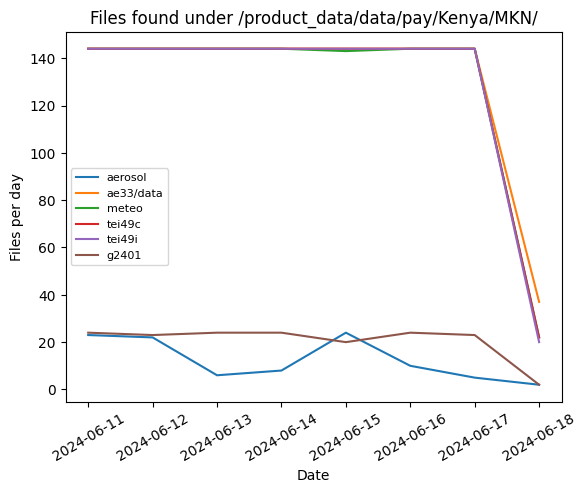

In [7]:
# organize MKN files on MeteoSwiss fileshare
n = hk.organize_files(mkn, branch="incoming", verbosity=1)

# show and plot file statistics
days = 7
stats = fc.get_file_coverage(cfg=mkn, days=days)
display(df:=fc.print_coverage(stats=stats, days=days))
fc.plot_coverage(stats=stats, days=days)

In [8]:
# relative path of level1 data .parquet files on repo
level1 = os.path.join("data", "level1")
os.makedirs(level1, exist_ok=True)

for k, v in mkn['branches'].items():
    if not os.path.exists(os.path.join(mkn['root'], v)):
        raise ValueError(f"path '{v}' not found.")

# path of source files
incoming = os.path.join(mkn['root'], mkn['branches']['incoming'])

# path of archive for successfully processed raw data files.
archive = os.path.join(mkn['root'], mkn['branches']['archive'])

# path for raw data files with issues
issues = os.path.join(mkn['root'], mkn['branches']['issues'])

# path for log files
logs = os.path.join(mkn['root'], mkn['branches']['logs'])

# instantiate instruments (rather, data types)
met = Meteo(log=os.path.join(logs, "meteo.log"))
thermo = Thermo(log=os.path.join(logs, "thermo.log"))
cpd2 = CPD2(log=os.path.join(logs, "cpd2.log"))
ae33 = AE33(log=os.path.join(logs, "ae33.log"))
g2401 = G2401(log=os.path.join(logs, "g2401.log"))

In [9]:
# display empty directories under source
# os.system(f"find {source} -empty -type d)

# display empty directories under source (NB: no questions asked!)
# os.system(f"find {source} -empty -type d -delete")

not a gzip file
cannot unpack non-iterable NoneType object
empty file
cannot unpack non-iterable NoneType object
dtm


Processing source /product_data/data/pay/Kenya/MKN/incoming/meteo/2021 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/tei49c/2021 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/tei49i/2021 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/aerosol/2021 ...
> Processing mkn_20210925T000006Z.tar ...
not a gzip file
cannot unpack non-iterable NoneType object
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2021/01 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2021/01 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2021/02 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2021/02 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2021/03 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2021/03 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2021/04 ...
Processing source /product_data/d

dtm


Processing source /product_data/data/pay/Kenya/MKN/incoming/tei49c/2024 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/tei49i/2024 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/aerosol/2024 ...
dtm
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2024/01 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2024/01 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2024/02 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2024/02 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2024/03 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2024/03 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2024/04 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2024/04 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2024/05 ...
Processing source /product_data/data/pay/Keny

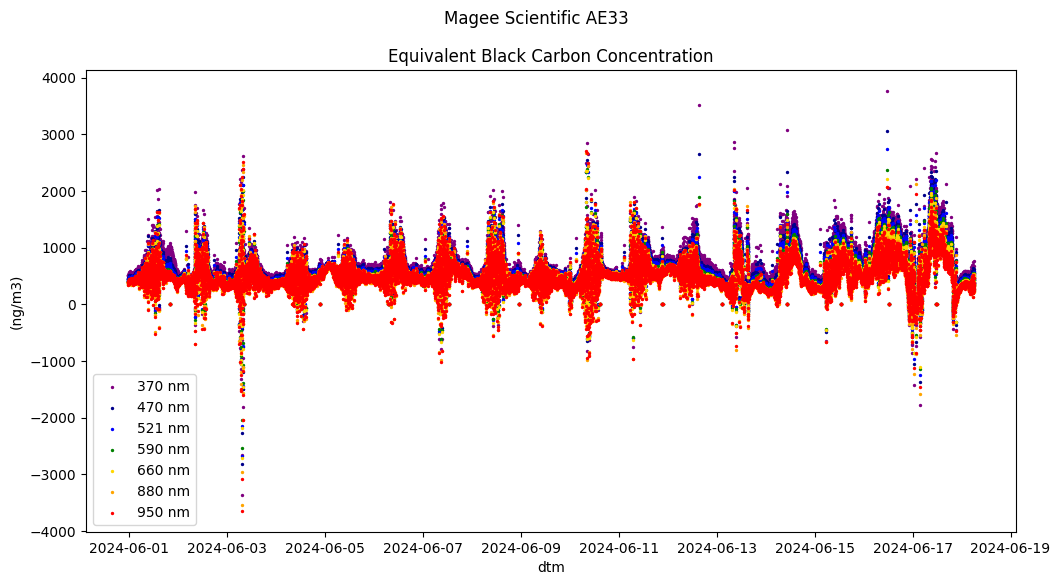

Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2024/06 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2024/07 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2024/07 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2024/08 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2024/08 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2024/09 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2024/09 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2024/10 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2024/10 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2024/11 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2024/11 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2024/12 ...
Processing source /product_data/data/pay

In [10]:
# process all raw data types
years = [f"{year}" for year in range(2021, 2025)]
months = ["{:02d}".format(mm) for mm in range(1, 13, 1)]

for year in years:
    met.compile_vrxa00_to_parquet(
        source=os.path.join(incoming, "meteo", year), 
        target=os.path.join(level1, year), 
        archive=os.path.join(archive, "meteo", year), 
        issues=os.path.join(issues, "meteo"),
        )
    thermo.compile_thermo_to_parquet(
        source=os.path.join(incoming, "tei49c", year),
        target=os.path.join(level1, year),
        archive=os.path.join(archive, "tei49c", year),
        issues=os.path.join(issues, "tei49c"),
        )        
    thermo.compile_thermo_to_parquet(
        source=os.path.join(incoming, "tei49i", year),
        target=os.path.join(level1, year),
        archive=os.path.join(archive, "tei49i", year),
        issues=os.path.join(issues, "tei49i"),
        )
    cpd2.tarballs_to_parquet(
        source=os.path.join(incoming, "aerosol", year), 
        target=os.path.join(level1, year), 
        archive=os.path.join(archive, "aerosol", year), 
        issues=os.path.join(issues, "aerosol"),
        )
    for month in months:
        if os.path.exists(incoming):
            ae33.zipfiles_to_parquet(
                source=os.path.join(incoming, "ae33", "data", year, month), 
                target=os.path.join(level1, year, month), 
                archive=os.path.join(archive, "ae33", "data", year, month), 
                issues=os.path.join(issues, "ae33"), 
                plot=True,
                )
            g2401.compile_g2401_to_parquet(
                source=os.path.join(incoming, "g2401", year, month), 
                target=os.path.join(level1, year, month), 
                archive=os.path.join(archive, "g2401", year, month), 
                issues=os.path.join(issues, "g2401"),
                )